In [1]:
# Cell 1 - Imports & Setup
import numpy as np
import matplotlib.pyplot as plt
import os

PROJECT_ROOT = os.path.abspath("..")
print("Setup done ✓")

Setup done ✓


In [3]:
# Cell 2 - Real results from actual runs
MOLECULE_NAMES = ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']

# RF results - from 02_random_forest_baseline.ipynb on 10K real data
rf_r2   = [0.755, 0.637, 0.847, 0.943, 0.559, -0.025, -0.020, -0.024, -0.026, -0.010, -0.025, -0.021]
rf_rmse = [0.668, 0.541, 0.211, 0.096, 0.536,  0.734,  0.952,  1.436,  1.538,  1.120,  1.123,  1.355]
rf_mae  = [0.468, 0.348, 0.168, 0.052, 0.387,  0.600,  0.773,  1.158,  1.229,  0.904,  0.909,  1.115]
rf_mean_r2 = 0.299

# XGBoost results - from xgboost_evaluate.py on 10K real data
xgb_r2   = [0.972, 0.978, 0.996, 1.000, 0.975, 0.670, 0.665, 0.670, 0.689, 0.689, 0.674, 0.671]
xgb_rmse = [0.228, 0.131, 0.035, 0.005, 0.129, 0.420, 0.548, 0.831, 0.832, 0.636, 0.622, 0.799]
xgb_mae  = [0.060, 0.034, 0.012, 0.001, 0.034, 0.188, 0.245, 0.370, 0.369, 0.284, 0.278, 0.358]
xgb_mean_r2 = 0.804

print("Data loaded ✓")
print(f"RF Mean R²  : {rf_mean_r2}")
print(f"XGB Mean R² : {xgb_mean_r2}")

Data loaded ✓
RF Mean R²  : 0.299
XGB Mean R² : 0.804


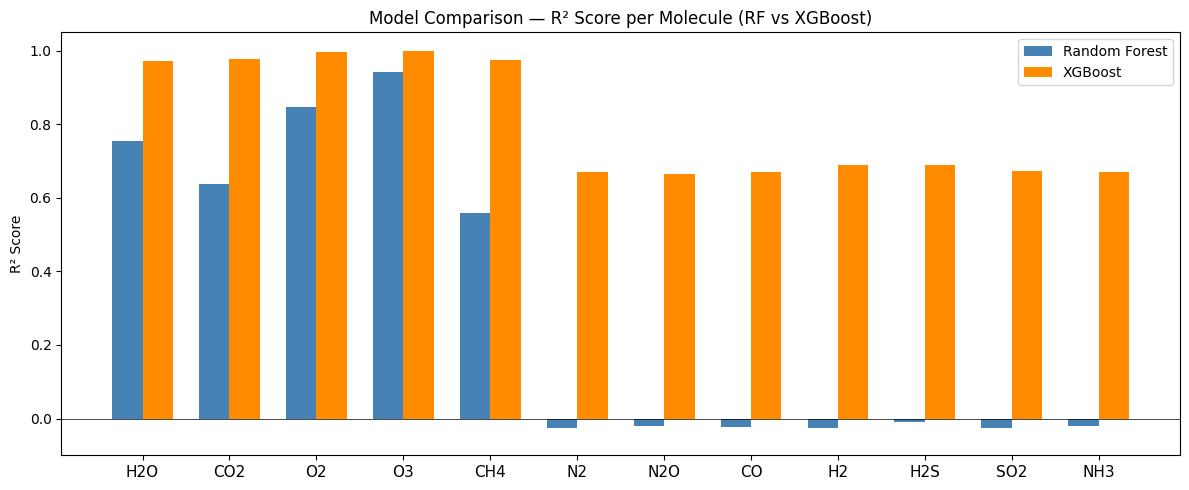

Saved ✓


In [4]:
# Cell 3 - R² Comparison Chart
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(MOLECULE_NAMES))
width = 0.35

bars1 = ax.bar(x - width/2, rf_r2, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_r2, width, label='XGBoost', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(MOLECULE_NAMES, fontsize=11)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — R² Score per Molecule (RF vs XGBoost)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.legend()
ax.set_ylim(-0.1, 1.05)

plt.tight_layout()
os.makedirs('../results/plots', exist_ok=True)
plt.savefig('../results/plots/model_comparison_r2.png', dpi=150)
plt.show()
print("Saved ✓")

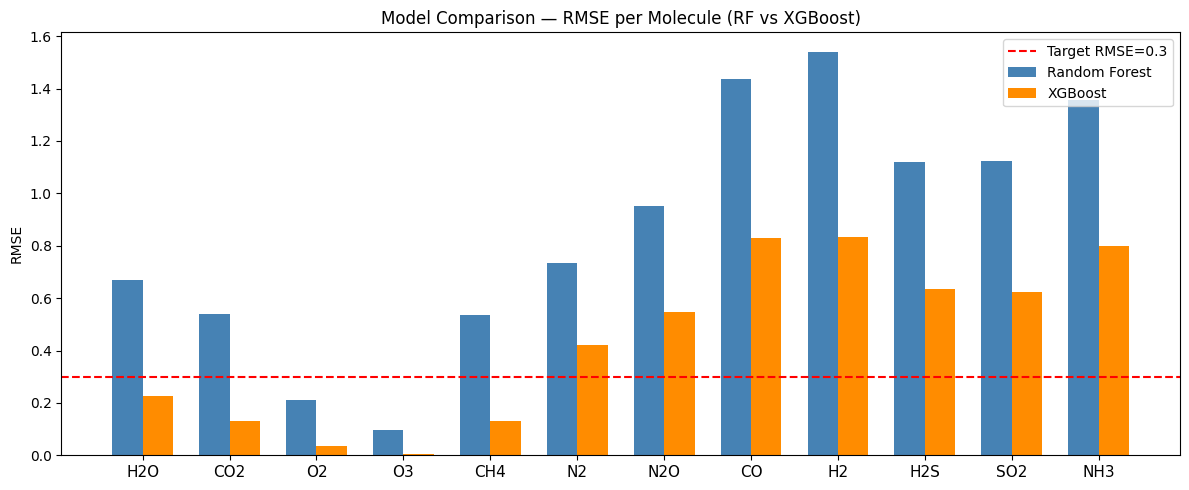

Saved ✓


In [7]:
# Cell 4 - RMSE Comparison Chart
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(MOLECULE_NAMES))
width = 0.35

bars1 = ax.bar(x - width/2, rf_rmse, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_rmse, width, label='XGBoost', color='darkorange')
ax.axhline(y=0.3, color='red', linestyle='--', label='Target RMSE=0.3')

ax.set_xticks(x)
ax.set_xticklabels(MOLECULE_NAMES, fontsize=11)
ax.set_ylabel('RMSE')
ax.set_title('Model Comparison — RMSE per Molecule (RF vs XGBoost)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../results/plots/model_comparison_rmse.png', dpi=150)
plt.show()
print("Saved ✓")

In [6]:
# Cell 5 - Summary Table
print("=" * 65)
print(f"{'MODEL COMPARISON SUMMARY':^65}")
print("=" * 65)
print(f"{'Molecule':<10} {'RF R²':>8} {'XGB R²':>8} {'RF RMSE':>10} {'XGB RMSE':>10} {'Improved':>10}")
print("-" * 65)
for i, mol in enumerate(MOLECULE_NAMES):
    improved = "✅ Yes" if xgb_r2[i] > rf_r2[i] else "❌ No"
    print(f"{mol:<10} {rf_r2[i]:>8.3f} {xgb_r2[i]:>8.3f} {rf_rmse[i]:>10.3f} {xgb_rmse[i]:>10.3f} {improved:>10}")
print("-" * 65)
print(f"{'MEAN':<10} {rf_mean_r2:>8.3f} {xgb_mean_r2:>8.3f}")
print("=" * 65)
print(f"\nOverall R² improvement: {rf_mean_r2:.3f} → {xgb_mean_r2:.3f} (+{xgb_mean_r2 - rf_mean_r2:.3f})")
print(f"Target: RMSE < 0.3 — still needs improvement for molecules 05-11")

                    MODEL COMPARISON SUMMARY                     
Molecule      RF R²   XGB R²    RF RMSE   XGB RMSE   Improved
-----------------------------------------------------------------
H2O           0.755    0.972      0.668      0.228      ✅ Yes
CO2           0.637    0.978      0.541      0.131      ✅ Yes
O2            0.847    0.996      0.211      0.035      ✅ Yes
O3            0.943    1.000      0.096      0.005      ✅ Yes
CH4           0.559    0.975      0.536      0.129      ✅ Yes
N2           -0.025    0.670      0.734      0.420      ✅ Yes
N2O          -0.020    0.665      0.952      0.548      ✅ Yes
CO           -0.024    0.670      1.436      0.831      ✅ Yes
H2           -0.026    0.689      1.538      0.832      ✅ Yes
H2S          -0.010    0.689      1.120      0.636      ✅ Yes
SO2          -0.025    0.674      1.123      0.622      ✅ Yes
NH3          -0.021    0.671      1.355      0.799      ✅ Yes
--------------------------------------------------------------